# Spider ML Task 1: Research Domain Experiment

This notebook extends the base Fashion-MNIST task to experimentally analyze label smoothing, as required in the Research Domain. It uses the same base architecture and compares normal training against multiple label smoothing values.

Run this in Google Colab after uploading `fashion-mnist_train.csv` and `fashion-mnist_test.csv` from the Kaggle Fashion-MNIST dataset.

## Research question

The assigned paper is "When Does Label Smoothing Help?" by Rafael Müller, Simon Kornblith, and Geoffrey Hinton. The paper studies why softening one-hot labels can improve generalization and calibration, while sometimes hurting knowledge distillation.

This notebook tests the idea on Fashion-MNIST by comparing:

- `label_smoothing = 0.00`: normal hard-label training
- `label_smoothing = 0.05`: mild smoothing
- `label_smoothing = 0.10`: standard smoothing
- `label_smoothing = 0.20`: stronger smoothing

The experiment tracks loss, accuracy, average prediction confidence, expected calibration error, and class-wise misclassifications.

In [1]:
# If PyTorch is missing in a fresh Colab runtime, uncomment:
# !pip install torch --quiet

import os
import random
import pickle
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

In [2]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)

BATCH_SIZE = 128
EPOCHS = 10
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-4
VALIDATION_RATIO = 0.15
SMOOTHING_VALUES = [0.0, 0.05, 0.10, 0.20, 0.40, 0.60, 0.80]

# Set True only for quick debugging. Keep False for final experiment.
RUN_FAST_DEMO = False
FAST_DEMO_TRAIN_ROWS = 8000
FAST_DEMO_TEST_ROWS = 1000

CLASS_NAMES = [
    "T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
    "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"
]
NUM_CLASSES = len(CLASS_NAMES)

Using device: cpu


In [3]:
def find_dataset_file(filename):
    search_roots = [
        Path("."), Path("/content"), Path("/content/data"), Path("/content/archive"),
        Path("/kaggle/input/fashionmnist"), Path("/kaggle/input/fashion-mnist"),
    ]
    for root in search_roots:
        candidate = root / filename
        if candidate.exists():
            return candidate
    for root in [Path("."), Path("/content"), Path("/kaggle/input")]:
        if root.exists():
            matches = list(root.rglob(filename))
            if matches:
                return matches[0]
    raise FileNotFoundError(f"Could not find {filename}. Upload the Kaggle CSV files and rerun.")


train_csv_path = find_dataset_file("fashion-mnist_train.csv")
test_csv_path = find_dataset_file("fashion-mnist_test.csv")

train_df = pd.read_csv(train_csv_path)
test_df = pd.read_csv(test_csv_path)

if RUN_FAST_DEMO:
    train_df = train_df.iloc[:FAST_DEMO_TRAIN_ROWS].copy()
    test_df = test_df.iloc[:FAST_DEMO_TEST_ROWS].copy()

print("Train shape:", train_df.shape)
print("Test shape :", test_df.shape)

Train shape: (60000, 785)
Test shape : (10000, 785)


In [4]:
def split_features_labels(df, has_labels=True):
    if has_labels and "label" in df.columns:
        y = df["label"].to_numpy(dtype=np.int64)
        pixels = df.drop(columns=["label"]).to_numpy(dtype=np.float32)
    else:
        y = None
        pixels = df.to_numpy(dtype=np.float32)
    x = (pixels / 255.0).reshape(-1, 1, 28, 28)
    x = torch.tensor(x, dtype=torch.float32)
    y = None if y is None else torch.tensor(y, dtype=torch.long)
    return x, y


X_all, y_all = split_features_labels(train_df, has_labels=True)
test_has_labels = "label" in test_df.columns
X_test, y_test = split_features_labels(test_df, has_labels=test_has_labels)

print(X_all.shape, y_all.shape)
print(X_test.shape, None if y_test is None else y_test.shape)

torch.Size([60000, 1, 28, 28]) torch.Size([60000])
torch.Size([10000, 1, 28, 28]) torch.Size([10000])


In [5]:
def make_loaders(X, y, validation_ratio=0.15, batch_size=128):
    n = len(X)
    indices = torch.randperm(n, generator=torch.Generator().manual_seed(SEED))
    val_size = int(n * validation_ratio)
    val_idx = indices[:val_size]
    train_idx = indices[val_size:]

    train_ds = TensorDataset(X[train_idx], y[train_idx])
    val_ds = TensorDataset(X[val_idx], y[val_idx])

    train_loader = DataLoader(
        train_ds, batch_size=batch_size, shuffle=True, num_workers=2,
        pin_memory=torch.cuda.is_available()
    )
    val_loader = DataLoader(
        val_ds, batch_size=batch_size, shuffle=False, num_workers=2,
        pin_memory=torch.cuda.is_available()
    )
    return train_loader, val_loader


train_loader, val_loader = make_loaders(X_all, y_all, VALIDATION_RATIO, BATCH_SIZE)
print("Train batches:", len(train_loader))
print("Val batches  :", len(val_loader))

Train batches: 399
Val batches  : 71


## Base architecture

In [6]:
class SpiderFashionMNISTNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()
        self.input_to_hidden = nn.Linear(28 * 28, 16)
        self.left_hidden_1 = nn.Linear(16, 8)
        self.left_hidden_2 = nn.Linear(8, 8)
        self.right_hidden_1 = nn.Linear(16, 12)
        self.right_hidden_2 = nn.Linear(12, 8)
        self.output_layer = nn.Linear(16, 10)
        self.activation = nn.ReLU()

    def forward(self, x):
        x = self.flatten(x)
        shared = self.activation(self.input_to_hidden(x))

        left_1 = self.activation(self.left_hidden_1(shared))
        left_2 = self.activation(self.left_hidden_2(left_1))
        left = left_1 + left_2

        right = self.activation(self.right_hidden_1(shared))
        right = self.activation(self.right_hidden_2(right))

        combined = torch.cat([left, right], dim=1)
        return self.output_layer(combined)

## Metrics: accuracy, confidence, calibration, and confusion matrix

In [7]:
def expected_calibration_error(confidences, correctness, n_bins=10):
    confidences = np.asarray(confidences)
    correctness = np.asarray(correctness).astype(float)
    ece = 0.0
    bin_edges = np.linspace(0.0, 1.0, n_bins + 1)

    for i in range(n_bins):
        left, right = bin_edges[i], bin_edges[i + 1]
        if i == n_bins - 1:
            mask = (confidences >= left) & (confidences <= right)
        else:
            mask = (confidences >= left) & (confidences < right)
        if mask.any():
            bin_conf = confidences[mask].mean()
            bin_acc = correctness[mask].mean()
            ece += (mask.mean()) * abs(bin_acc - bin_conf)
    return float(ece)


def update_confusion_matrix(confusion, labels, preds):
    for true_label, pred_label in zip(labels.cpu().numpy(), preds.cpu().numpy()):
        confusion[int(true_label), int(pred_label)] += 1
    return confusion

In [8]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss, total_correct, total_examples = 0.0, 0, 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        logits = model(images)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()

        batch_size = labels.size(0)
        total_loss += loss.item() * batch_size
        total_correct += (logits.argmax(dim=1) == labels).sum().item()
        total_examples += batch_size

    return total_loss / total_examples, total_correct / total_examples


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, total_correct, total_examples = 0.0, 0, 0
    all_confidences = []
    all_correctness = []
    confusion = np.zeros((NUM_CLASSES, NUM_CLASSES), dtype=np.int64)

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        logits = model(images)
        loss = criterion(logits, labels)
        probs = torch.softmax(logits, dim=1)
        confidences, preds = probs.max(dim=1)
        correct = preds == labels

        batch_size = labels.size(0)
        total_loss += loss.item() * batch_size
        total_correct += correct.sum().item()
        total_examples += batch_size
        all_confidences.extend(confidences.cpu().numpy().tolist())
        all_correctness.extend(correct.cpu().numpy().tolist())
        confusion = update_confusion_matrix(confusion, labels, preds)

    avg_confidence = float(np.mean(all_confidences))
    ece = expected_calibration_error(all_confidences, all_correctness, n_bins=10)
    return {
        "loss": total_loss / total_examples,
        "accuracy": total_correct / total_examples,
        "avg_confidence": avg_confidence,
        "ece": ece,
        "confusion": confusion,
    }

## Run label smoothing experiments

In [9]:
def run_experiment(label_smoothing):
    torch.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)

    model = SpiderFashionMNISTNet().to(DEVICE)
    criterion = nn.CrossEntropyLoss(label_smoothing=label_smoothing)
    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=LEARNING_RATE,
        weight_decay=WEIGHT_DECAY,
    )

    history = {
        "train_loss": [], "train_accuracy": [],
        "val_loss": [], "val_accuracy": [],
        "val_avg_confidence": [], "val_ece": [],
    }
    best_val_accuracy = -1.0
    best_state = None
    best_confusion = None

    for epoch in range(1, EPOCHS + 1):
        train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, DEVICE)
        val_metrics = evaluate(model, val_loader, criterion, DEVICE)

        history["train_loss"].append(train_loss)
        history["train_accuracy"].append(train_acc)
        history["val_loss"].append(val_metrics["loss"])
        history["val_accuracy"].append(val_metrics["accuracy"])
        history["val_avg_confidence"].append(val_metrics["avg_confidence"])
        history["val_ece"].append(val_metrics["ece"])

        if val_metrics["accuracy"] > best_val_accuracy:
            best_val_accuracy = val_metrics["accuracy"]
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            best_confusion = val_metrics["confusion"].copy()

        print(
            f"eps={label_smoothing:.2f} | epoch {epoch:02d}/{EPOCHS} | "
            f"train_loss={train_loss:.4f} train_acc={train_acc:.4f} | "
            f"val_loss={val_metrics['loss']:.4f} val_acc={val_metrics['accuracy']:.4f} | "
            f"conf={val_metrics['avg_confidence']:.4f} ece={val_metrics['ece']:.4f}"
        )

    model.load_state_dict(best_state)
    return {
        "label_smoothing": label_smoothing,
        "model_state_dict": best_state,
        "history": history,
        "best_val_accuracy": best_val_accuracy,
        "best_confusion": best_confusion,
    }


experiment_results = []
for eps in SMOOTHING_VALUES:
    print("\n" + "=" * 80)
    print(f"Training model with label_smoothing={eps}")
    print("=" * 80)
    experiment_results.append(run_experiment(eps))


Training model with label_smoothing=0.0
eps=0.00 | epoch 01/10 | train_loss=1.0210 train_acc=0.6227 | val_loss=0.6216 val_acc=0.7692 | conf=0.7458 ece=0.0314
eps=0.00 | epoch 02/10 | train_loss=0.5665 train_acc=0.7958 | val_loss=0.5375 val_acc=0.7991 | conf=0.8040 ece=0.0158
eps=0.00 | epoch 03/10 | train_loss=0.5039 train_acc=0.8228 | val_loss=0.4868 val_acc=0.8266 | conf=0.8077 ece=0.0188
eps=0.00 | epoch 04/10 | train_loss=0.4698 train_acc=0.8361 | val_loss=0.4728 val_acc=0.8332 | conf=0.8214 ece=0.0118
eps=0.00 | epoch 05/10 | train_loss=0.4481 train_acc=0.8431 | val_loss=0.4462 val_acc=0.8408 | conf=0.8274 ece=0.0136
eps=0.00 | epoch 06/10 | train_loss=0.4340 train_acc=0.8472 | val_loss=0.4451 val_acc=0.8427 | conf=0.8342 ece=0.0107
eps=0.00 | epoch 07/10 | train_loss=0.4229 train_acc=0.8512 | val_loss=0.4300 val_acc=0.8491 | conf=0.8360 ece=0.0158
eps=0.00 | epoch 08/10 | train_loss=0.4130 train_acc=0.8552 | val_loss=0.4320 val_acc=0.8469 | conf=0.8451 ece=0.0089
eps=0.00 | epoc

## Summary table

In [10]:
summary_rows = []
for result in experiment_results:
    h = result["history"]
    summary_rows.append({
        "label_smoothing": result["label_smoothing"],
        "best_val_accuracy": result["best_val_accuracy"],
        "final_train_accuracy": h["train_accuracy"][-1],
        "final_val_accuracy": h["val_accuracy"][-1],
        "final_train_loss": h["train_loss"][-1],
        "final_val_loss": h["val_loss"][-1],
        "final_avg_confidence": h["val_avg_confidence"][-1],
        "final_ece": h["val_ece"][-1],
    })

summary_df = pd.DataFrame(summary_rows)
summary_df.to_csv("label_smoothing_experiment_summary.csv", index=False)
summary_df

,label_smoothing,best_val_accuracy,final_train_accuracy,final_val_accuracy,final_train_loss,final_val_loss,final_avg_confidence,final_ece
0,0.00,0.852000,0.860725,0.852000,0.397000,0.415405,0.846688,0.007238
1,0.05,0.858667,0.865196,0.858667,0.644580,0.658216,0.795853,0.062897
2,0.10,0.861333,0.866510,0.861333,0.827321,0.836761,0.753833,0.107500
3,0.20,0.859889,0.865255,0.859889,1.132785,1.141697,0.680860,0.179547
4,0.40,0.859111,0.868588,0.859111,1.605155,1.612339,0.537492,0.321619
5,0.60,0.857222,0.866098,0.857222,1.961822,1.966975,0.385108,0.472115
6,0.80,0.856778,0.859137,0.856778,2.203434,2.204028,0.241419,0.615461


## Plot loss, accuracy, confidence, and calibration

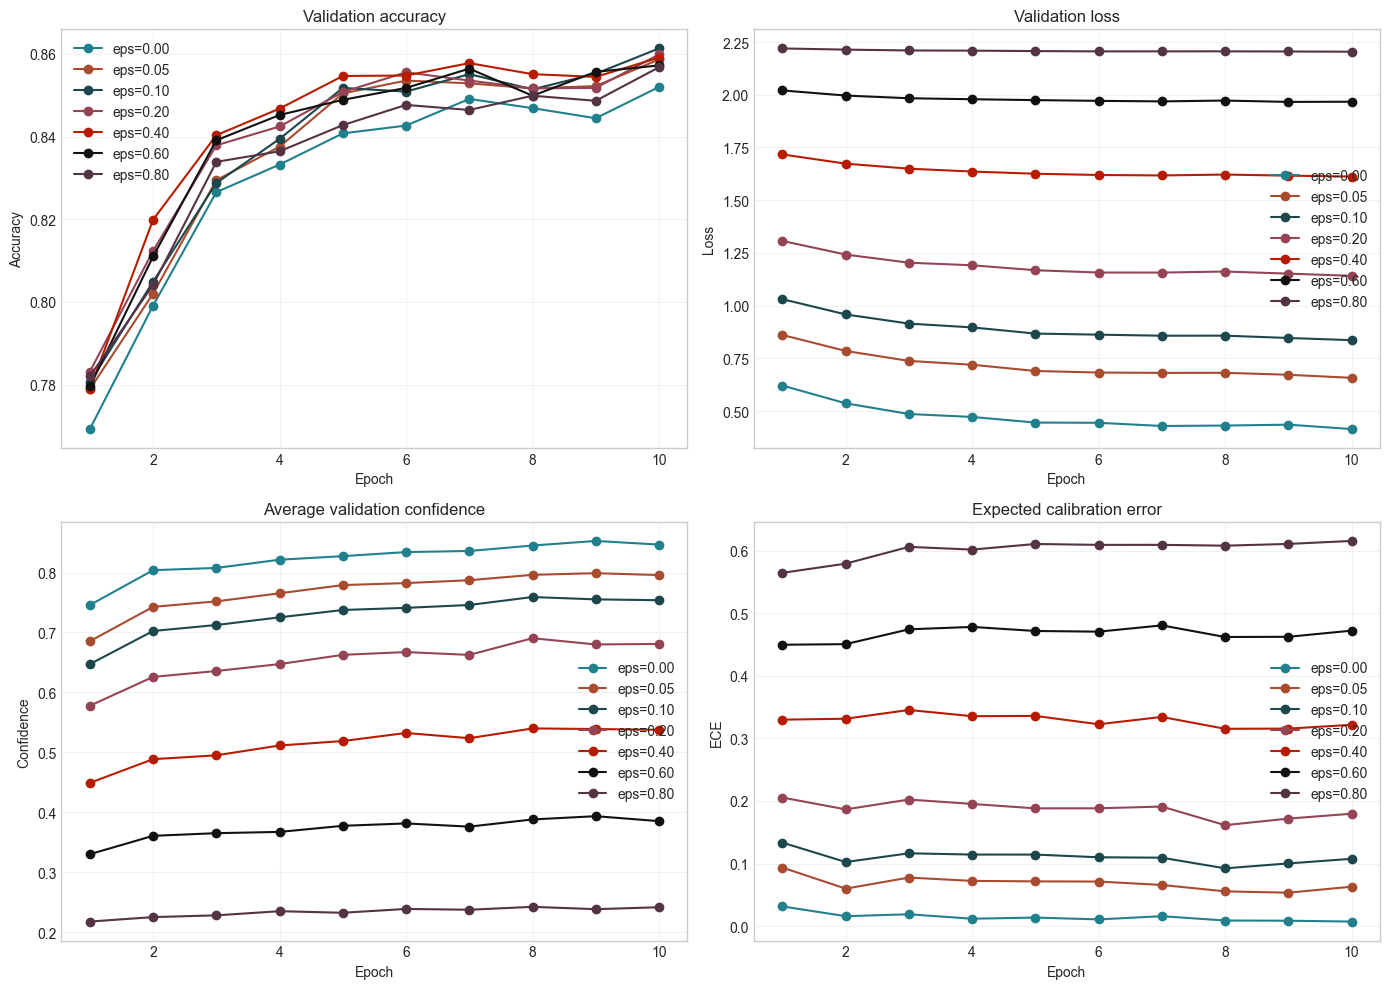

In [11]:
plt.style.use("seaborn-v0_8-whitegrid")
colors = ["#20808D", "#A84B2F", "#1B474D", "#944454", "#B81C00", "#121111","#543345"]
epochs = np.arange(1, EPOCHS + 1)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for result, color in zip(experiment_results, colors):
    eps = result["label_smoothing"]
    label = f"eps={eps:.2f}"
    h = result["history"]
    axes[0, 0].plot(epochs, h["val_accuracy"], marker="o", color=color, label=label)
    axes[0, 1].plot(epochs, h["val_loss"], marker="o", color=color, label=label)
    axes[1, 0].plot(epochs, h["val_avg_confidence"], marker="o", color=color, label=label)
    axes[1, 1].plot(epochs, h["val_ece"], marker="o", color=color, label=label)

axes[0, 0].set_title("Validation accuracy")
axes[0, 0].set_xlabel("Epoch")
axes[0, 0].set_ylabel("Accuracy")

axes[0, 1].set_title("Validation loss")
axes[0, 1].set_xlabel("Epoch")
axes[0, 1].set_ylabel("Loss")

axes[1, 0].set_title("Average validation confidence")
axes[1, 0].set_xlabel("Epoch")
axes[1, 0].set_ylabel("Confidence")

axes[1, 1].set_title("Expected calibration error")
axes[1, 1].set_xlabel("Epoch")
axes[1, 1].set_ylabel("ECE")

for ax in axes.ravel():
    ax.legend()
    ax.grid(alpha=0.25)

plt.tight_layout()
plt.savefig("label_smoothing_training_curves.png", dpi=200, bbox_inches="tight")
plt.show()

## Plot final metric comparison

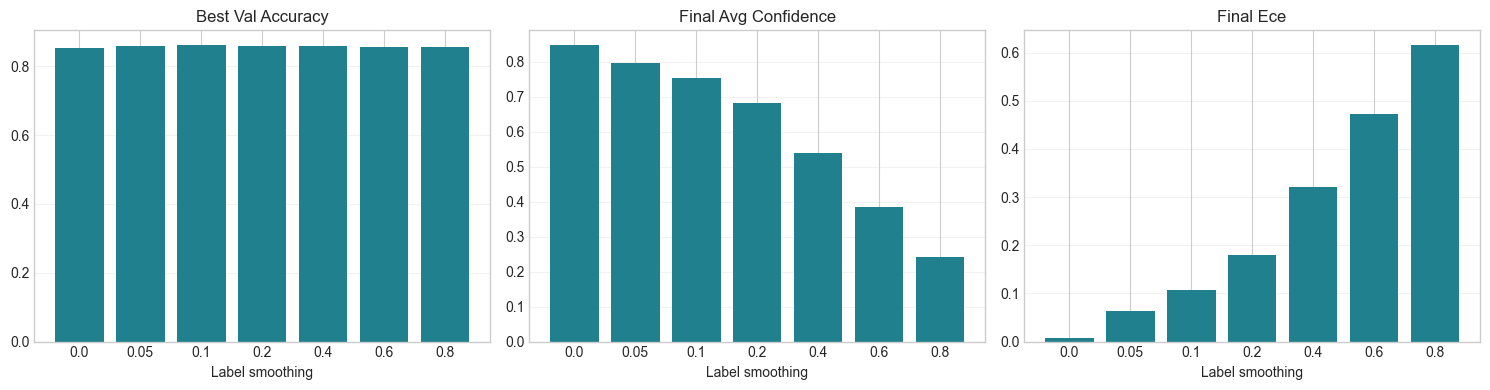

In [13]:
metric_names = ["best_val_accuracy", "final_avg_confidence", "final_ece"]
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, metric in zip(axes, metric_names):
    ax.bar(summary_df["label_smoothing"].astype(str), summary_df[metric], color="#20808D")
    ax.set_title(metric.replace("_", " ").title())
    ax.set_xlabel("Label smoothing")
    ax.grid(axis="y", alpha=0.25)

plt.tight_layout()
plt.savefig("label_smoothing_metric_comparison.png", dpi=200, bbox_inches="tight")
plt.show()

## Confusion matrix for the best smoothing value

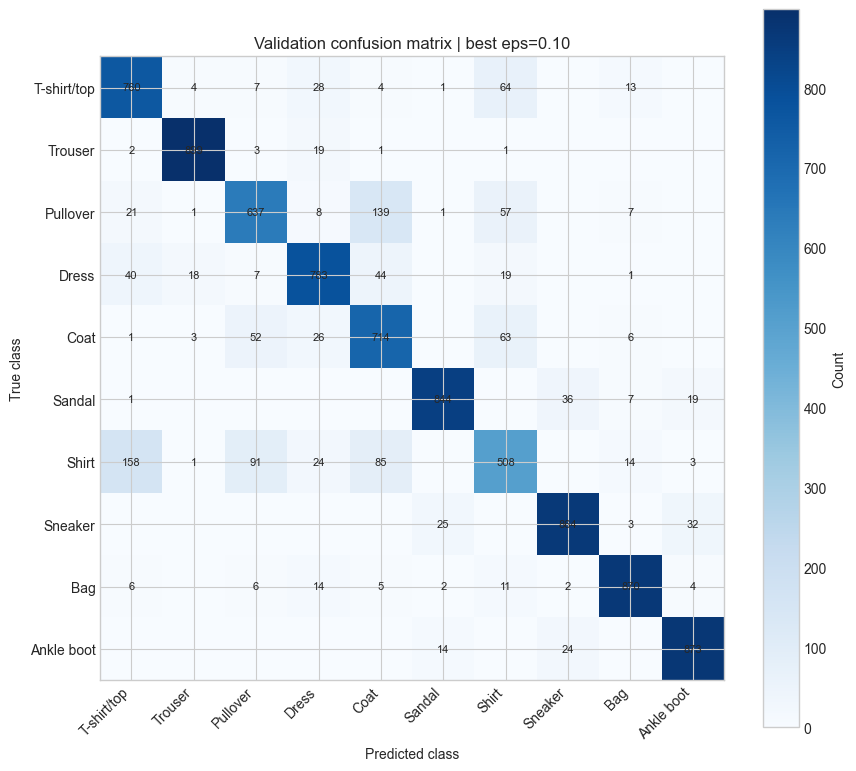

Best smoothing value by validation accuracy: 0.1


In [14]:
best_result = max(experiment_results, key=lambda r: r["best_val_accuracy"])
best_eps = best_result["label_smoothing"]
confusion = best_result["best_confusion"]

plt.figure(figsize=(9, 8))
plt.imshow(confusion, cmap="Blues")
plt.title(f"Validation confusion matrix | best eps={best_eps:.2f}")
plt.xlabel("Predicted class")
plt.ylabel("True class")
plt.xticks(range(NUM_CLASSES), CLASS_NAMES, rotation=45, ha="right")
plt.yticks(range(NUM_CLASSES), CLASS_NAMES)
plt.colorbar(label="Count")

for i in range(NUM_CLASSES):
    for j in range(NUM_CLASSES):
        value = confusion[i, j]
        if value > 0:
            plt.text(j, i, str(value), ha="center", va="center", fontsize=8)

plt.tight_layout()
plt.savefig("label_smoothing_best_confusion_matrix.png", dpi=200, bbox_inches="tight")
plt.show()

print("Best smoothing value by validation accuracy:", best_eps)

In [15]:
misclassification_rows = []
for i, true_name in enumerate(CLASS_NAMES):
    row = confusion[i].copy()
    correct = row[i]
    row[i] = 0
    most_confused_idx = int(row.argmax())
    misclassification_rows.append({
        "true_class": true_name,
        "correct_count": int(correct),
        "most_confused_with": CLASS_NAMES[most_confused_idx],
        "confused_count": int(row[most_confused_idx]),
    })

misclassification_df = pd.DataFrame(misclassification_rows)
misclassification_df.to_csv("label_smoothing_classwise_misclassifications.csv", index=False)
misclassification_df

,true_class,correct_count,most_confused_with,confused_count
0,T-shirt/top,760,Shirt,64
1,Trouser,899,Dress,19
2,Pullover,637,Coat,139
3,Dress,783,Coat,44
4,Coat,714,Shirt,63
5,Sandal,844,Sneaker,36
6,Shirt,508,T-shirt/top,158
7,Sneaker,864,Ankle boot,32
8,Bag,870,Dress,14
9,Ankle boot,873,Sneaker,24


## Save best model weights and experiment results

In [16]:
best_model_path = "label_smoothing_best_model_weights.pkl"
all_results_path = "label_smoothing_all_experiment_results.pkl"

with open(best_model_path, "wb") as f:
    pickle.dump({
        "best_label_smoothing": best_eps,
        "model_state_dict": best_result["model_state_dict"],
        "class_names": CLASS_NAMES,
        "summary": summary_df.to_dict(orient="records"),
    }, f)

with open(all_results_path, "wb") as f:
    pickle.dump(experiment_results, f)

print("Saved:", best_model_path)
print("Saved:", all_results_path)

Saved: label_smoothing_best_model_weights.pkl
Saved: label_smoothing_all_experiment_results.pkl


## Generate predictions using the best research-domain model

In [19]:
best_model = SpiderFashionMNISTNet().to(DEVICE)
best_model.load_state_dict(best_result["model_state_dict"])
best_model.eval()

@torch.no_grad()
def predict_labels(model, X, batch_size=512):
    loader = DataLoader(TensorDataset(X), batch_size=batch_size, shuffle=False)
    preds = []
    confidences = []
    for (images,) in loader:
        images = images.to(DEVICE)
        logits = model(images)
        probs = torch.softmax(logits, dim=1)
        conf, pred = probs.max(dim=1)
        preds.append(pred.cpu())
        confidences.append(conf.cpu())
    return torch.cat(preds).numpy(), torch.cat(confidences).numpy()


test_predictions, test_confidences = predict_labels(best_model, X_test)
research_submission = pd.DataFrame({
    "id": np.arange(len(test_predictions)),
    "label": test_predictions.astype(int),
    "confidence": test_confidences,
})
research_submission.to_csv("label_smoothing_submission.csv", index=False)
research_submission.head()

,id,label,confidence
0,0,0,0.708402
1,1,1,0.943728
2,2,2,0.465641
3,3,2,0.440961
4,4,1,0.457356


In [21]:
if y_test is not None:
    test_accuracy = (test_predictions == y_test.numpy()).mean()
    print(f"Label smoothing model test accuracy: {test_accuracy:.4f}")
else:
    print("Generated label_smoothing_submission.csv. Test labels were not available.")

Label smoothing model test accuracy: 0.8591
